# imports

In [1]:
from pathlib import Path
from typing import Any
import json

from jaxtyping import Float
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import umap

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import (
	DistanceTensorResult,
)
from attention_motifs.features.plotting import (
	plot_embedding,
)
from attention_motifs.attnpedia.attnpedia import AttentionPedia

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

# load data

In [4]:
DF_PCA: pl.DataFrame = pl.read_ndjson(PATH_BASE / "pca.jsonl")

# distances between heads

In [5]:
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.build_distance_tensor(
	DF_PCA,
	feature_prefix="pc.",
)
dbg_tensor(HEAD_DISTS.distances)
dbg_tensor(HEAD_DISTS.mean_dists)
HEAD_DISTS.save_means(PATH_BASE / "head_dists.json")
print()

[ <ipykernel>:5 ] HEAD_DISTS.distances: μ=10.51 σ=4.93 x̃=9.62 R=[0.00,43.65] ℙ=|▂█▃    | shape=(1520,1520,128) dtype=float64
[ <ipykernel>:6 ] HEAD_DISTS.mean_dists: μ=10.51 σ=4.48 x̃=9.62 R=[0.00,34.04] ℙ=| █▅▁   | shape=(1520,1520) dtype=float64


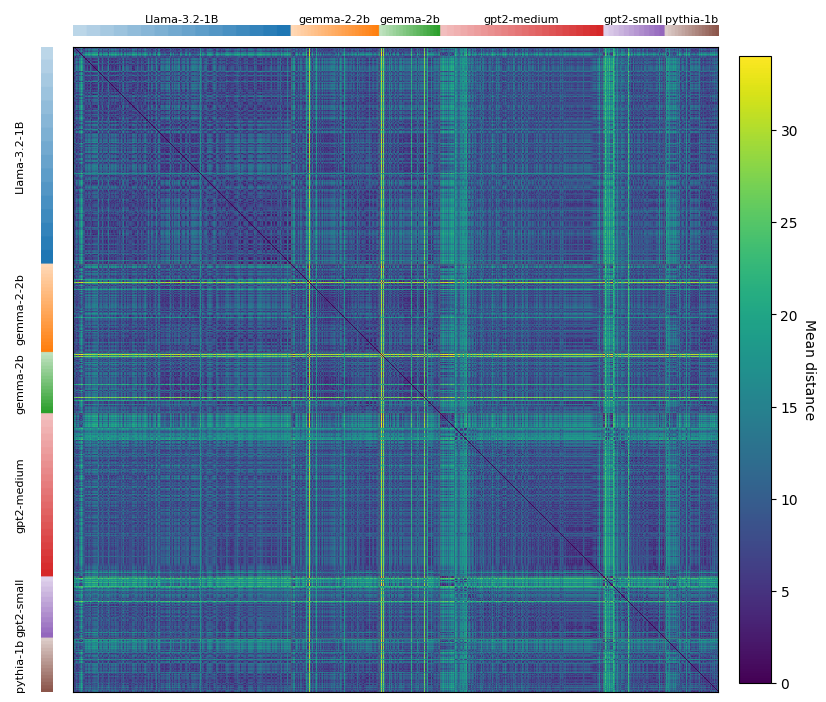

In [14]:
def parse_cls(cls: str) -> tuple[str, int, int]:
	"""
	Split ``{model}:L{layer}:H{head}`` into (model, layer, head).
	"""
	model_part, layer_part, head_part = cls.split(":")
	layer = int(layer_part[1:])  # drop leading "L"
	head = int(head_part[1:])  # drop leading "H"
	return model_part, layer, head


def plot_heatmap(
	self,
	*,
	figsize: tuple[int, int] = (9, 9),
	stripe_thickness: float = 0.018,
	top_label_space: float = 0.04,
	left_label_space: float = 0.08,
	model_font: int = 8,     # ← pass size here (default a bit smaller)
	layer_font: int = 7,     # kept but no longer used
	major_grid_colour: str = "red",
	minor_grid_colour: str = "red",
	show: bool = True,
) -> plt.Figure:
	"""
	Draw the distance matrix with:

	* rows / columns sorted by (model, layer, head);
	* colour stripes encoding model (hue) + depth (lightness);
	* model labels on both axes (no layer numbers);
	* red grid (major at model boundaries).
	"""
	# ---------------- sort -------------------------------------------------
	parsed_entries: list[tuple[str, int, int]] = [parse_cls(t) for t in self.cls_values]
	sort_indices: list[int] = sorted(
		range(len(self.cls_values)), key=lambda i: parsed_entries[i]
	)
	sorted_entries: list[tuple[str, int, int]] = [parsed_entries[i] for i in sort_indices]
	distance_matrix: np.ndarray = self.mean_dists[np.ix_(sort_indices, sort_indices)]
	size: int = len(sorted_entries)

	# ---------------- colours ---------------------------------------------
	models: list[str] = sorted({model for model, _, _ in sorted_entries})
	model_rgb: dict[str, tuple[float, float, float]] = {
		model: plt.cm.tab10(i)[:3] for i, model in enumerate(models)
	}

	max_layer_for_model: dict[str, int] = {}
	for model, layer, _ in sorted_entries:
		max_layer_for_model[model] = max(max_layer_for_model.get(model, -1), layer)

	def entry_rgba(entry: tuple[str, int, int]) -> tuple[float, float, float, float]:
		model, layer, _ = entry
		base_rgb = np.asarray(model_rgb[model])
		depth_scale = (
			0.3 + 0.7 * (layer / max_layer_for_model[model])
			if max_layer_for_model[model]
			else 0.5
		)
		blended_rgb = base_rgb * depth_scale + (1.0 - depth_scale)
		return (*blended_rgb, 1.0)

	rgba_entries: list[tuple[float, float, float, float]] = [entry_rgba(e) for e in sorted_entries]
	stripe_top: np.ndarray = np.array(rgba_entries).reshape(1, -1, 4)
	stripe_left: np.ndarray = np.array(rgba_entries).reshape(-1, 1, 4)  # ← no reverse

	# ---------------- figure / main heat-map -------------------------------
	figure, axis_main = plt.subplots(figsize=figsize)
	heat_img = axis_main.matshow(distance_matrix)
	axis_main.set_xticks([])
	axis_main.set_yticks([])
	axis_main.set_aspect("equal")

	# ---------------- stripes ------------------------------------------------
	axis_top = axis_main.inset_axes(
		[0, 1.0 + top_label_space * 0.4, 1, stripe_thickness],
		transform=axis_main.transAxes,
		sharex=axis_main,
	)
	axis_top.imshow(stripe_top, aspect="auto", origin="upper")
	axis_top.set_axis_off()

	axis_left = axis_main.inset_axes(
		[-stripe_thickness - left_label_space * 0.4, 0, stripe_thickness, 1],
		transform=axis_main.transAxes,
		sharey=axis_main,
	)
	axis_left.imshow(stripe_left, aspect="auto", origin="upper")
	axis_left.set_axis_off()

	# ---------------- model-label axes --------------------------------------
	axis_top_labels = axis_main.inset_axes(
		[0, 1.0 + stripe_thickness + top_label_space * 0.2, 1, top_label_space * 0.8],
		transform=axis_main.transAxes,
		sharex=axis_main,
	)
	axis_top_labels.set_axis_off()

	axis_left_labels = axis_main.inset_axes(
		[-stripe_thickness - left_label_space, 0, top_label_space * 0.8, 1],
		transform=axis_main.transAxes,
		sharey=axis_main,
	)
	axis_left_labels.set_axis_off()

	# ---------------- spans & gridlines -------------------------------------
	model_spans: dict[str, list[int]] = {}
	for index, (model, layer, _) in enumerate(sorted_entries):
		model_spans.setdefault(model, [index, index])[1] = index  # extend end

	# boundaries
	model_boundaries: list[float] = [
		end + 0.5 for _, (_, end) in model_spans.items() if end + 1 < size
	]

	for boundary in model_boundaries:
		axis_main.axvline(boundary, color=major_grid_colour, lw=0.1, zorder=2)
		axis_main.axhline(boundary, color=major_grid_colour, lw=0.1, zorder=2)

	# ---------------- annotations (model names only) ------------------------
	for model, (start, end) in model_spans.items():
		center: float = (start + end) / 2

		axis_top_labels.text(
			center, 0.5, model, ha="center", va="center", fontsize=model_font
		)
		axis_left_labels.text(
			0.5, center, model, ha="center", va="center", fontsize=model_font, rotation=90
		)

	# ---------------- colour-bar --------------------------------------------
	colour_bar = figure.colorbar(heat_img, ax=axis_main, fraction=0.045, pad=0.03)
	colour_bar.ax.set_ylabel("Mean distance", rotation=270, labelpad=13)

	if show:
		plt.show()
	return figure


fig = plot_heatmap(HEAD_DISTS, show=False)
fig.savefig(
	"figures/head-dists-heatmap.pdf",
	bbox_inches="tight",
	pad_inches=0.1,
)

In [ ]:
ATTENTIONPEDIA: AttentionPedia = AttentionPedia()

In [ ]:
HEAD_DISTS.get_closest_heads("gpt2-small:L5:H5", n_closest=10)
# 'gpt2-medium:L5:H8

# for k in HEAD_DISTS.cls_values:
# 	plt.plot(
# 		[
# 			x[1]
# 			for x in HEAD_DISTS.get_closest_heads(k, n_closest=50)[1:]
# 		],
# 		alpha=0.05,
# 		color="black",
# 	)

# plt.show()

In [ ]:
# HEAD_DISTS.plot_hists(n_samples=64)

In [ ]:
from attention_motifs.features.head_analysis import filter_umap_warns


filter_umap_warns()

n_neighbors_lst: list[int] = [2, 4, 8, 16]  # , 32, 64, 128, 256, 512]
fig, ax_hm = plt.subplots(
	nrows=1,
	ncols=len(n_neighbors_lst),
	figsize=(10 * len(n_neighbors_lst), 10),
)
for i, n_neighbors in enumerate(n_neighbors_lst):
	reducer: umap.UMAP = umap.UMAP(
		n_components=2,
		metric="precomputed",
		init="spectral",
		n_neighbors=n_neighbors,
		min_dist=0.1,
		random_state=0,
	)
	embedding: np.ndarray = reducer.fit_transform(HEAD_DISTS.mean_dists)

	# scatter plot
	attnpedia_head_to_type: dict[str, str] = AttentionPedia().head_to_type()
	plot_embedding(
		embedding,
		# labels=pl.Series([f.split(":")[0] for f in head_dists.cls_values]),
		labels=pl.Series(
			[attnpedia_head_to_type.get(f, "unknown") for f in HEAD_DISTS.cls_values]
		),
		dims=(0, 1),
		alpha={
			"unknown": 0.2,
			None: 0.9,
		},
		marker_size={
			"unknown": 10,
			None: 30,
		},
		title=f"UMAP embedding ({n_neighbors = })",
		ax=ax_hm[i],
	)
plt.show()

# plt.figure(figsize=(8, 6))
# plt.scatter(embedding[:, 0], embedding[:, 1], s=10)  # no explicit colours
# plt.xlabel("UMAP 0")
# plt.ylabel("UMAP 1")
# plt.title("UMAP embedding")
# plt.tight_layout()
# plt.show()

In [ ]:
def plot_hclust(
	dist_mat: Float[np.ndarray, "h h"],
	labels: list[str],
	*,
	method: str = "average",
	leaf_font_size: int = 6,
	truncate: int | None = None,
	show_heatmap: bool = True,
) -> tuple[np.ndarray, list[str], dict[str, Any]]:
	"""Hierarchical clustering dendrogram (plus optional heat-map).

	# Parameters
	 - `dist_mat : Float[np.ndarray, "h h"]`
	    Square distance matrix (symmetric, zero diagonal).
	 - `labels : list[str]`
	    Observation names, length `h`.
	 - `method : str`
	    Linkage criterion for `scipy.cluster.hierarchy.linkage`.
	 - `leaf_font_size : int`
	    Tick-label font size.
	 - `truncate : int | None`
	    If given, plot the dendrogram in *last-p* mode with `p = truncate`.
	 - `show_heatmap : bool`
	    Draw reordered distance matrix.
	 - `figsize : tuple[int, int] | None`
	    Figure size; if `None`, pick a reasonable default.

	# Returns
	 - `np.ndarray`
	    Linkage matrix `Z` (`h - 1`, 4).
	 - `dict[str, Any]`
	    Dot-list representation of the tree **as actually plotted**
	    (clusters are collapsed when `truncate` is used).
	"""
	h: int = dist_mat.shape[0]

	# ---------- sanity checks
	if dist_mat.shape != (h, h):
		raise ValueError("dist_mat must be square")
	if len(labels) != h:
		raise ValueError("labels length must match dist_mat")
	if not np.allclose(dist_mat, dist_mat.T):
		raise ValueError("dist_mat must be symmetric")
	if not np.all(np.diag(dist_mat) == 0):
		raise ValueError("dist_mat diagonal must be zero")

	# ---------- linkage
	condensed: Float[np.ndarray, "h*(h-1)//2"] = squareform(dist_mat, checks=False)
	Z: np.ndarray = linkage(condensed, method=method)

	# ---------- dendrogram
	_, ax_dend = plt.subplots(figsize=(8, 4))
	dend_kw: dict[str, object] = {
		"labels": labels,
		"leaf_rotation": 90,
		"leaf_font_size": leaf_font_size,
		"distance_sort": "ascending",
	}
	if truncate is not None:
		dend_kw.update({"truncate_mode": "lastp", "p": truncate})

	dendro: dict[str, Any] = dendrogram(Z, **dend_kw, ax=ax_dend)
	ax_dend.set_ylabel("Distance")
	ax_dend.set_title(f"Hierarchical clustering ({method} linkage)")
	# ax_dend.set_ylim(7, 27)
	plt.tight_layout()
	plt.show()

	# ---------- helpers
	def _members(node_id: int, *, n: int = h) -> list[int]:
		"""Return all original leaf indices contained in `node_id`."""
		if node_id < n:
			return [node_id]
		left: int = int(Z[node_id - n, 0])
		right: int = int(Z[node_id - n, 1])
		return _members(left, n=n) + _members(right, n=n)

	visible_ids: set[int] = set(dendro["leaves"])

	# ---------- heat-map
	order: list[int]
	if truncate is None:
		order = list(dendro["leaves"])
	else:
		order = [idx for node in dendro["leaves"] for idx in _members(node)]
	labels_ordered: list[str] = [labels[i] for i in order]
	if show_heatmap:
		reordered: Float[np.ndarray, "h h"] = dist_mat[np.ix_(order, order)]

		_, ax_hm = plt.subplots(figsize=(30, 30))
		im = ax_hm.imshow(reordered, aspect="auto")
		ax_hm.set_xticks(np.arange(h))
		ax_hm.set_yticks(np.arange(h))
		ax_hm.set_xticklabels(labels_ordered, rotation=90, fontsize=leaf_font_size)
		ax_hm.set_yticklabels(labels_ordered, fontsize=leaf_font_size)
		ax_hm.set_xlabel("Classes")
		ax_hm.set_ylabel("Classes")
		ax_hm.set_title("Distance matrix (reordered)")
		ax_hm.set_aspect("equal")
		plt.colorbar(im, ax=ax_hm)
		plt.tight_layout()
		plt.show()

	# ---------- dot-list
	def _dot_tree(node_id: int, path: str = "") -> dict[str, Any]:
		key: str = path.rstrip(".") or "root"
		if node_id in visible_ids:  # displayed leaf/cluster
			mem: list[int] = _members(node_id)
			return {key: labels[mem[0]] if len(mem) == 1 else [labels[m] for m in mem]}
		left, right = (int(x) for x in Z[node_id - h, :2])
		dot: dict[str, Any] = {}
		dot.update(_dot_tree(left, f"{path}0."))
		dot.update(_dot_tree(right, f"{path}1."))
		return dot

	tree_dict: dict[str, Any] = _dot_tree(2 * h - 2)

	return Z, labels_ordered, tree_dict


linkages, labels_sorted, tree = plot_hclust(
	HEAD_DISTS.mean_dists,
	labels=HEAD_DISTS.cls_values,
	truncate=100,
	# show_heatmap=False,
)

dbg_tensor(linkages)
leaf_lens: dict[str, int] = {k: len(v) for k, v in tree.items()}
plt.hist(
	leaf_lens.values(),
	bins=50,
)
plt.show()
print(
	json.dumps(
		leaf_lens,
		indent=2,
	)
)

In [ ]:
import itertools

tree_known_types: dict[str, set[str]] = {
	k: set(
		itertools.chain.from_iterable(
			[ATTENTIONPEDIA.head_to_types().get(h, ["unknown"]) for h in v]
		)
	)
	for k, v in tree.items()
}
tree_known_types

In [ ]:
known_types_to_leaf: dict[str, set[str]] = {
	t: set([head for head, types in tree_known_types.items() if t in types])
	for t in [*ATTENTIONPEDIA.type_to_heads().keys(), "unknown"]
}
known_types_to_leaf